In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from ml_from_scratch.neural_networks.neural_network import NeuralNetwork
from ml_from_scratch.preprocessing.scaler import MyStandardScaler

from ml_from_scratch.metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss
)

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Classes:', np.unique(y))

X shape: (569, 30)
y shape: (569,)
Classes: [0 1]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                    test_size = 0.2, random_state = 22, stratify = y)

In [5]:
scaler = MyStandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
np.random.seed(22)

model = NeuralNetwork(input_size = 30, hidden_size = 16, output_size = 1, learning_rate = 0.05, n_iterations = 2000)

model.fit(X_train_scaled, y_train)

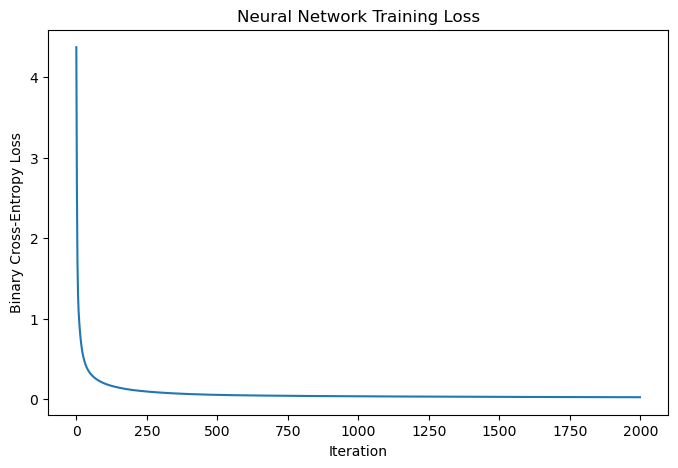

In [7]:
plt.figure(figsize = (8, 5))

plt.plot(model.loss_history)

plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Neural Network Training Loss')

plt.show()

In [8]:
y_proba = model.predict_proba(X_test_scaled).reshape(-1)

y_pred = model.predict(X_test_scaled).reshape(-1)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
loss = log_loss(y_test, y_proba)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'Log Loss : {loss:.4f}')

Accuracy : 0.9649
Precision: 0.9722
Recall   : 0.9722
F1 Score : 0.9722
Log Loss : 0.1048


In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  2]
 [ 2 70]]


In [11]:
for threshold in [0.3, 0.5]:
    predictions = (y_proba >= threshold).astype(int)
    print('=' * 50)
    print(f'Threshold: {threshold}')
    print('=' * 50)
    print(f'Accuracy : {accuracy_score(y_test, predictions):.4f}')
    print(f'Precision: {precision_score(y_test, predictions):.4f}')
    print(f'Recall   : {recall_score(y_test, predictions):.4f}')
    print(f'F1 Score : {f1_score(y_test, predictions):.4f}')

Threshold: 0.3
Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1 Score : 0.9793
Threshold: 0.5
Accuracy : 0.9649
Precision: 0.9722
Recall   : 0.9722
F1 Score : 0.9722


In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)
import time

sklearn_model = MLPClassifier(hidden_layer_sizes = (16,), activation = 'relu', solver = 'sgd',
            learning_rate_init = 0.05, max_iter = 2000, random_state = 22)

start = time.perf_counter()

sklearn_model.fit(X_train_scaled, y_train)

training_time = time.perf_counter() - start

sklearn_proba = sklearn_model.predict_proba(X_test_scaled)[:, 1]
sklearn_pred = (sklearn_proba >= 0.5).astype(int)

print(f'Training Time: {training_time:.6f}s')
print(f'Accuracy     : {accuracy_score(y_test, sklearn_pred):.4f}')
print(f'Precision    : {precision_score(y_test, sklearn_pred):.4f}')
print(f'Recall       : {recall_score(y_test, sklearn_pred):.4f}')
print(f'F1 Score     : {f1_score(y_test, sklearn_pred):.4f}')
print(f'Log Loss     : {log_loss(y_test, sklearn_proba):.4f}')

Training Time: 0.202793s
Accuracy     : 0.9474
Precision    : 0.9714
Recall       : 0.9444
F1 Score     : 0.9577
Log Loss     : 0.1679


In [13]:
custom_metrics = {
    
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'Log Loss': log_loss(y_test, y_proba),
}

sklearn_metrics = {
    'Accuracy': accuracy_score(y_test, sklearn_pred),
    'Precision': precision_score(y_test, sklearn_pred),
    'Recall': recall_score(y_test, sklearn_pred),
    'F1': f1_score(y_test, sklearn_pred),
    'Log Loss': log_loss(y_test, sklearn_proba),
}

comparison = pd.DataFrame(
    {
        'My custom Neural Network': custom_metrics,
        'Sklearn MLP': sklearn_metrics,
    }
)

comparison

,My custom Neural Network,Sklearn MLP
Accuracy,0.964912,0.947368
Precision,0.972222,0.971429
Recall,0.972222,0.944444
F1,0.972222,0.957746
Log Loss,0.104751,0.167850


# Final Interpretation

The custom Neural Network achieved strong performance on the Breast Cancer Wisconsin
classification task.

At the default threshold of 0.5, the model achieved 96.49% accuracy, 97.22%
precision, 97.22% recall, and 97.22% F1 score, with a log loss of 0.1048.

Threshold selection was also evaluated because different classification errors can
have different consequences. Lowering the threshold from 0.5 to 0.3 increased
recall from 97.22% to 98.61% and F1 score from 97.22% to 97.93%. Accuracy also
increased from 96.49% to 97.37%. This demonstrates that the classification
threshold can affect model performance and should be considered based on the
application's objective.

The custom implementation was compared with sklearn's MLPClassifier using a
similar single-hidden-layer architecture. In this experiment, the custom model
achieved better test-set metrics than the sklearn reference model. However, this
does not imply that the custom implementation is generally superior. The two
models use different optimization and implementation details, and the comparison
is based on a single train/test split.

The main objective of this experiment was therefore not to outperform sklearn,
but to verify that the custom implementation produces a valid learning model
with reasonable predictive performance.

Overall, this project demonstrated the complete workflow of implementing and
evaluating a neural network from scratch using NumPy, including forward
propagation, backpropagation, gradient checking, optimization, evaluation,
threshold analysis, and comparison with a standard machine learning library.